In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('star_classification.csv')

In [3]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
df.drop(columns=['obj_ID','delta','cam_col','field_ID','alpha','fiber_ID'],inplace=True)

In [5]:
df.head()

,u,g,r,i,z,run_ID,rerun_ID,spec_obj_ID,class,redshift,plate,MJD
0,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,6.543777e+18,GALAXY,0.634794,5812,56354
1,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,1.176014e+19,GALAXY,0.779136,10445,58158
2,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,5.152200e+18,GALAXY,0.644195,4576,55592
3,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,1.030107e+19,GALAXY,0.932346,9149,58039
4,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,6.891865e+18,GALAXY,0.116123,6121,56187


In [6]:
df.drop(columns=['run_ID','rerun_ID'],inplace=True)

In [7]:
df.drop(columns=['spec_obj_ID'],inplace=True)

In [8]:
df.drop(columns=['MJD','plate'],inplace=True)

In [9]:
df.describe()

,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.980468,20.531387,19.645762,19.084854,18.668810,0.576661
std,31.769291,31.750292,1.854760,1.757895,31.728152,0.730707
min,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,-0.009971
25%,20.352353,18.965230,18.135828,17.732285,17.460677,0.054517
50%,22.179135,21.099835,20.125290,19.405145,19.004595,0.424173
75%,23.687440,22.123767,21.044785,20.396495,19.921120,0.704154
max,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


In [10]:
df = df.replace(-9999.0, np.nan)
df[['u', 'g', 'r', 'i', 'z']] = df[['u', 'g', 'r', 'i', 'z']].fillna(
    df[['u', 'g', 'r', 'i', 'z']].median()
)

In [11]:
df.head()

,u,g,r,i,z,class,redshift
0,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


#Data Visualization

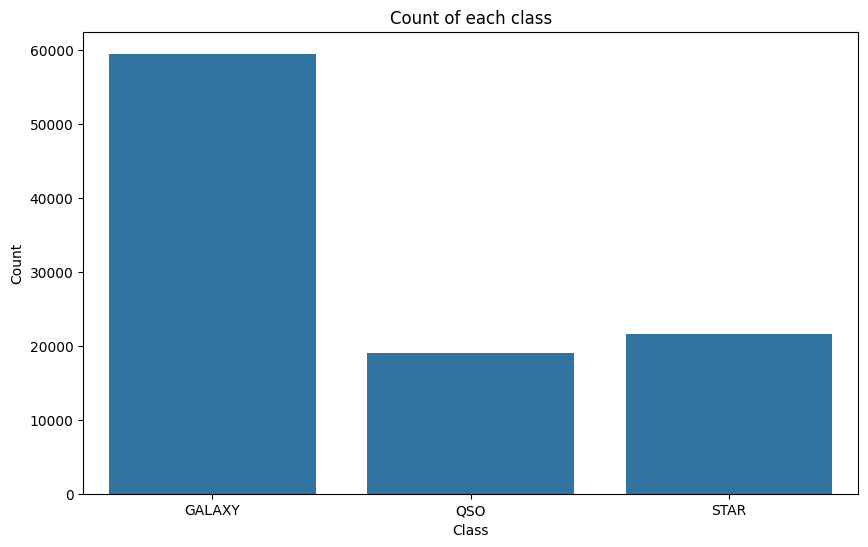

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class')
plt.title('Count of each class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [13]:
df.describe()

,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,22.080680,20.631588,19.645762,19.084854,18.768990,0.576661
std,2.251057,2.037374,1.854760,1.757895,1.765973,0.730707
min,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,20.352430,18.965245,18.135828,17.732285,17.460900,0.054517
50%,22.179140,21.099930,20.125290,19.405145,19.004600,0.424173
75%,23.687440,22.123767,21.044785,20.396495,19.921120,0.704154
max,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   u         100000 non-null  float64
 1   g         100000 non-null  float64
 2   r         100000 non-null  float64
 3   i         100000 non-null  float64
 4   z         100000 non-null  float64
 5   class     100000 non-null  object 
 6   redshift  100000 non-null  float64
dtypes: float64(6), object(1)
memory usage: 5.3+ MB


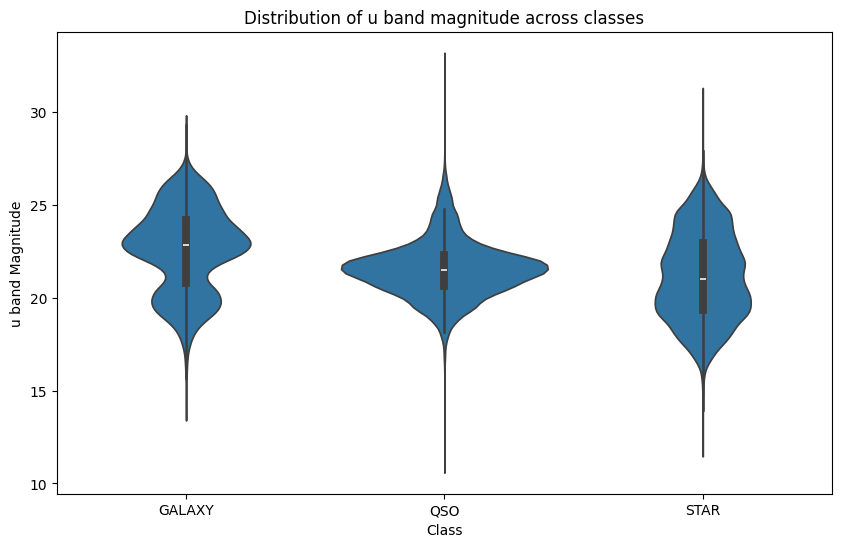

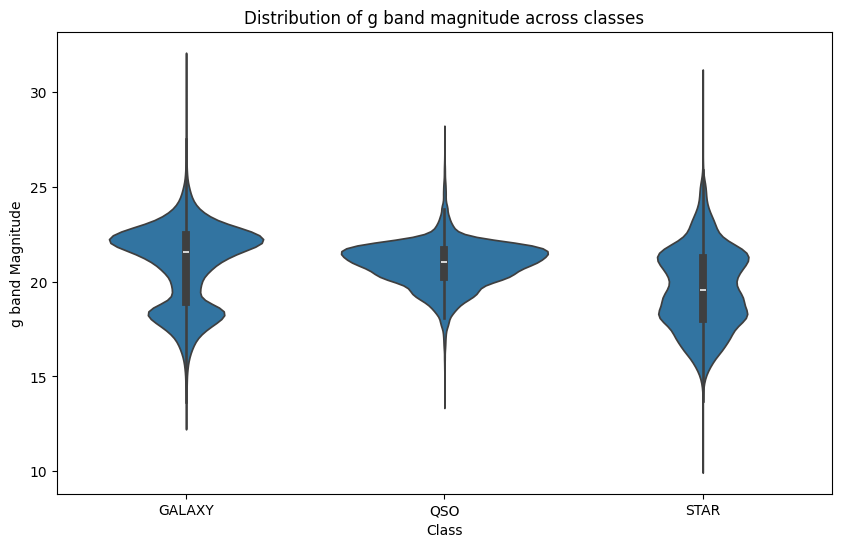

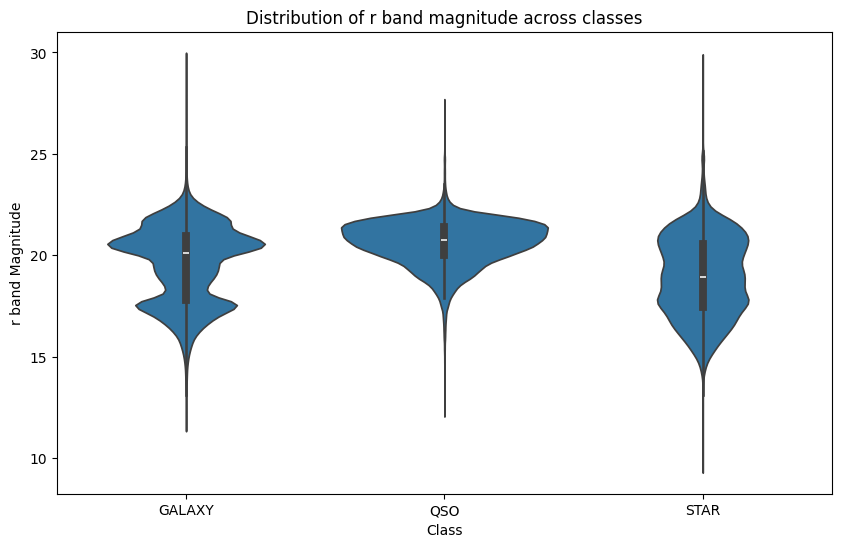

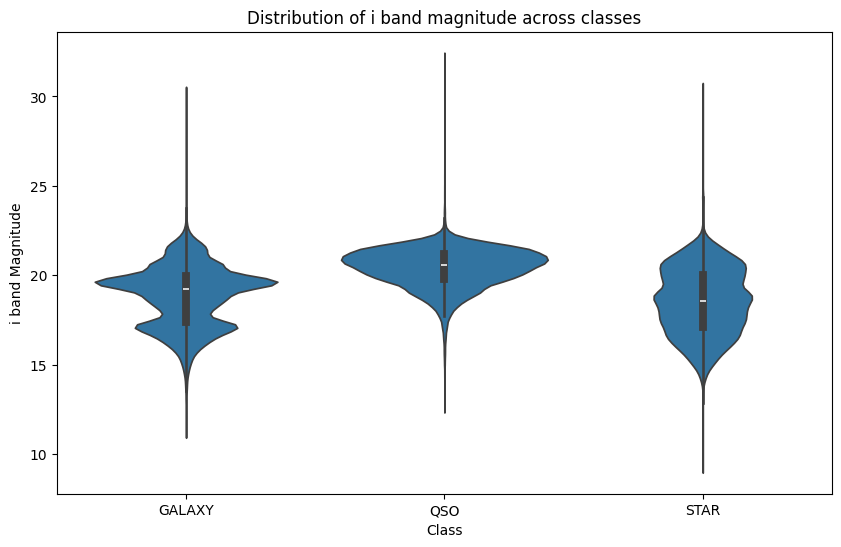

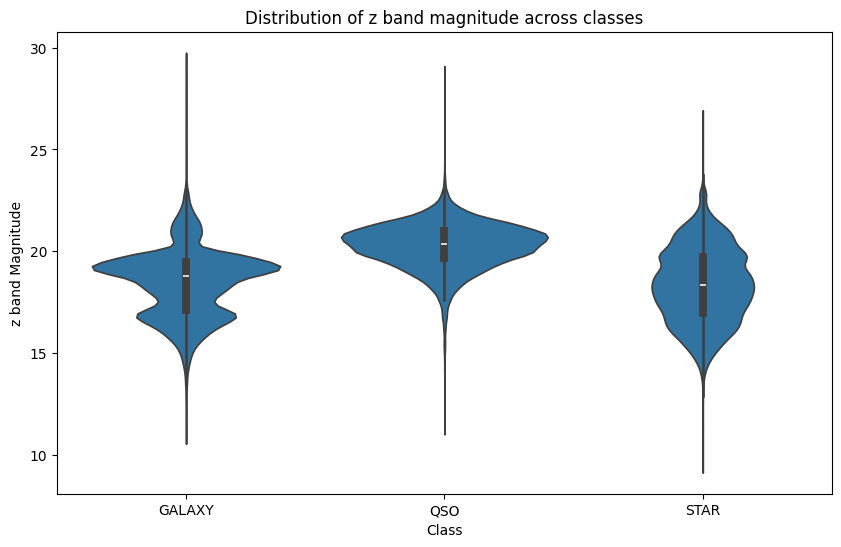

In [15]:
color_bands = ['u', 'g', 'r', 'i', 'z']

for band in color_bands:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='class', y=band, data=df)
    plt.title(f'Distribution of {band} band magnitude across classes')
    plt.xlabel('Class')
    plt.ylabel(f'{band} band Magnitude')
    plt.show()

#Train test split

In [16]:
X = df.drop(columns=['class'])
y = df['class']

In [17]:
X.shape

(100000, 6)

In [18]:
y.value_counts()

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


#Encoding the target

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [20]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

#Scaling the features

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Training the Model

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

#Evaluation of Model

Accuracy: 0.9577

              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     11889
         QSO       0.95      0.88      0.92      3792
        STAR       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



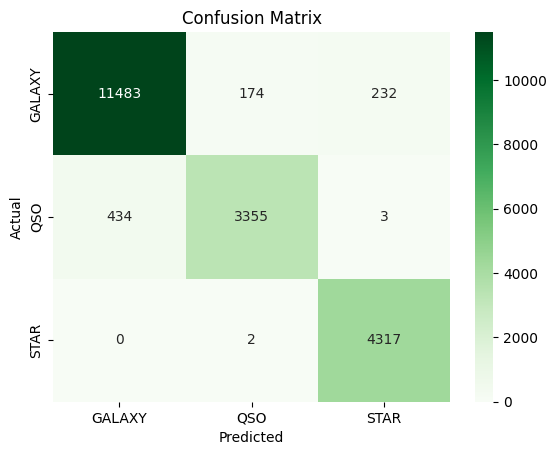

In [24]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
import numpy as np

sample_data = pd.DataFrame({
    'u': [20.28],
    'g': [18.16],
    'r': [17.00],
    'i': [16.51],
    'z': [16.13],
    'redshift': [0.1474]
})

print("Sample data for prediction:")
print(sample_data)

Sample data for prediction:
       u      g     r      i      z  redshift
0  20.28  18.16  17.0  16.51  16.13    0.1474


In [27]:
sample_scaled = scaler.transform(sample_data)
prediction = model.predict(sample_scaled)
prediction_prob = model.predict_proba(sample_scaled)
print(f"Predicted class: {le.inverse_transform(prediction)[0]}")
print(f"Prediction probabilities: {prediction_prob[0]}")

Predicted class: GALAXY
Prediction probabilities: [9.83078406e-01 1.68562989e-02 6.52953275e-05]


#Downloading the model

In [29]:
import joblib

In [30]:
pipeline = {
    'model': model,
    'scaler': scaler,
    'label_encoder': le,
    'features': list(X.columns)
}
joblib.dump(pipeline, 'star_model.pkl')

['star_model.pkl']